In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/content/drive/MyDrive/TA_SER')


FEATURES_ROOT    = PROJECT_ROOT / 'data' / 'processed' / 'features_v4'
LABEL_ENCODER_FP = PROJECT_ROOT / 'data' / 'processed' / 'label_encoder.json'
MODEL_DIR        = PROJECT_ROOT / 'saved_models' / 'v4'
REPORTS_DIR      = PROJECT_ROOT / 'reports'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE       = 32
MAX_EPOCHS       = 100
LEARNING_RATE    = 0.001
LABEL_SMOOTHING  = 0.1
L2_REG           = 0.0002
DROPOUT_CONV     = 0.25
DROPOUT_DENSE    = 0.5
PATIENCE_ES      = 15
PATIENCE_LR      = 7
LR_FACTOR        = 0.5
MIN_LR           = 1e-6

MODEL_NAME       = 'model_A'
FILTERS_CONV1    = 64
FILTERS_CONV2    = 128
FILTERS_CONV3    = 256
KERNEL_SIZE      = 5
DENSE_UNITS      = 128

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_SHAPE = (188, 40)
NUM_CLASSES = 4

print(f'TF version: {tf.__version__}')
print(f'Model name: {MODEL_NAME}')
print(f'Input shape: {INPUT_SHAPE}')
print(f'Num classes: {NUM_CLASSES}')


Mounted at /content/drive
TF version: 2.19.0
Model name: model_A
Input shape: (188, 40)
Num classes: 4


In [ ]:
with open(LABEL_ENCODER_FP, 'r') as f:
    label_enc = json.load(f)

LABEL_TO_INT  = label_enc['label_to_int']
INT_TO_LABEL  = {int(k): v for k, v in label_enc['int_to_label'].items()}
TARGET_LABELS = label_enc['target_labels']

print(f'Target labels: {TARGET_LABELS}')
print(f'Label to int : {LABEL_TO_INT}')


Target labels: ['angry', 'happy', 'neutral', 'sad']
Label to int : {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3}


In [ ]:
X_train = np.load(FEATURES_ROOT / 'train' / 'X_train.npy')
y_train = np.load(FEATURES_ROOT / 'train' / 'y_train.npy')
sources_train = np.load(FEATURES_ROOT / 'train' / 'sources_train.npy', allow_pickle=True)

y_train_oh = to_categorical(y_train, num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}  y_train_oh: {y_train_oh.shape}')
print(f'sources_train: {sources_train.shape}  unique: {np.unique(sources_train, return_counts=True)}')

val_per_source = {}
for src in ['ravdess', 'emodb', 'tess', 'savee']:
    X_v = np.load(FEATURES_ROOT / 'val' / f'X_val_{src}.npy')
    y_v = np.load(FEATURES_ROOT / 'val' / f'y_val_{src}.npy')
    val_per_source[src] = {
        'X': X_v,
        'y': y_v,
        'y_oh': to_categorical(y_v, num_classes=NUM_CLASSES)
    }
    print(f'  val_{src}: X={X_v.shape}  y={y_v.shape}')

X_val_combined = np.load(FEATURES_ROOT / 'val' / 'X_val_combined.npy')
y_val_combined = np.load(FEATURES_ROOT / 'val' / 'y_val_combined.npy')
sources_val_combined = np.load(FEATURES_ROOT / 'val' / 'sources_val_combined.npy', allow_pickle=True)
y_val_combined_oh = to_categorical(y_val_combined, num_classes=NUM_CLASSES)

print(f'\n X_val_combined: {X_val_combined.shape}  y_val_combined_oh: {y_val_combined_oh.shape}')


X_train: (9312, 188, 40)  y_train: (9312,)  y_train_oh: (9312, 4)
sources_train: (9312,)  unique: (array(['emodb', 'ravdess', 'savee', 'tess'], dtype=object), array([1084, 2148,  960, 5120]))
  val_ravdess: X=(67, 188, 40)  y=(67,)
  val_emodb: X=(34, 188, 40)  y=(34,)
  val_tess: X=(160, 188, 40)  y=(160,)
  val_savee: X=(30, 188, 40)  y=(30,)

 X_val_combined: (291, 188, 40)  y_val_combined_oh: (291, 4)


In [ ]:
def build_model_A(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name='input')

    x = layers.Conv1D(
        FILTERS_CONV1, kernel_size=KERNEL_SIZE, padding='same',
        kernel_regularizer=keras.regularizers.l2(L2_REG), name='conv1'
    )(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(DROPOUT_CONV, name='drop1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='maxpool1')(x)

    x = layers.Conv1D(
        FILTERS_CONV2, kernel_size=KERNEL_SIZE, padding='same',
        kernel_regularizer=keras.regularizers.l2(L2_REG), name='conv2'
    )(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(DROPOUT_CONV, name='drop2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='maxpool2')(x)

    x = layers.Conv1D(
        FILTERS_CONV3, kernel_size=KERNEL_SIZE, padding='same',
        kernel_regularizer=keras.regularizers.l2(L2_REG), name='conv3'
    )(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.Dropout(DROPOUT_CONV, name='drop3')(x)

    x = layers.GlobalAveragePooling1D(name='gap')(x)

    x = layers.Dense(
        DENSE_UNITS, activation='relu',
        kernel_regularizer=keras.regularizers.l2(L2_REG), name='dense1'
    )(x)
    x = layers.Dropout(DROPOUT_DENSE, name='drop_dense')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=MODEL_NAME)
    return model


model = build_model_A()
model.summary()
total_params = model.count_params()
print(f'\n Total params: {total_params:,}')


Model: "model_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 188, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 188, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 188, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 188, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 188, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling1D)         │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 94, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 94, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 94, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 94, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2 (MaxPooling1D)         │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 47, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 47, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 47, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 47, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,252 (989.27 KB)

 Trainable params: 252,356 (985.77 KB)

 Non-trainable params: 896 (3.50 KB)


 Total params: 253,252


In [ ]:
loss_fn = CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)
optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

print(f'Loss: CategoricalCrossentropy(label_smoothing={LABEL_SMOOTHING})')
print(f'Optimizer: Adam(lr={LEARNING_RATE})')
print(f'Metrics: accuracy')


Loss: CategoricalCrossentropy(label_smoothing=0.1)
Optimizer: Adam(lr=0.001)
Metrics: accuracy


In [ ]:
class PerSourceValAccCallback(Callback):

    def __init__(self, val_per_source):
        super().__init__()
        self.val_per_source = val_per_source
        self.history_per_source = {src: [] for src in val_per_source.keys()}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        per_src_str = []
        for src, data in self.val_per_source.items():

            y_pred = self.model.predict(data['X'], verbose=0)
            y_pred_class = np.argmax(y_pred, axis=1)
            acc = np.mean(y_pred_class == data['y'])
            self.history_per_source[src].append(float(acc))

            logs[f'val_acc_{src}'] = float(acc)
            per_src_str.append(f'{src}={acc:.3f}')

        print(" | val_acc_per_src: {' '.join(per_src_str)}")


per_source_callback = PerSourceValAccCallback(val_per_source)
print('Custom callback initialized')


Custom callback initialized


In [ ]:
checkpoint_path = MODEL_DIR / f'{MODEL_NAME}_best.h5'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE_ES,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        patience=PATIENCE_LR,
        factor=LR_FACTOR,
        min_lr=MIN_LR,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    ),
    per_source_callback
]

print(f'Callbacks:')
print(f'  - EarlyStopping (val_loss, patience={PATIENCE_ES})')
print(f'  - ReduceLROnPlateau (val_loss, patience={PATIENCE_LR}, factor={LR_FACTOR})')
print(f'  - ModelCheckpoint (save_best_only) → {checkpoint_path}')


Callbacks:
  - EarlyStopping (val_loss, patience=15)
  - ReduceLROnPlateau (val_loss, patience=7, factor=0.5)
  - ModelCheckpoint (save_best_only) → /content/drive/MyDrive/TA_SER/saved_models/v4/model_A_best.h5


In [ ]:
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val_combined, y_val_combined_oh),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

print(f'\n Training complete')
print(f'  Final epoch: {len(history.history["loss"])}')
print(f'  Best val_loss: {min(history.history["val_loss"]):.4f}')
print(f'  Best val_acc: {max(history.history["val_accuracy"]):.4f}')


Epoch 1/100
289/291 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6797 - loss: 1.0224

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.7584 - loss: 0.9008 - val_accuracy: 0.8179 - val_loss: 0.7864 - learning_rate: 0.0010 - val_acc_ravdess: 0.5672 - val_acc_emodb: 0.6765 - val_acc_tess: 1.0000 - val_acc_savee: 0.5667
Epoch 2/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8224 - loss: 0.7855 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8385 - loss: 0.7586 - val_accuracy: 0.8041 - val_loss: 0.7876 - learning_rate: 0.0010 - val_acc_ravdess: 0.5373 - val_acc_emodb: 0.7353 - val_acc_tess: 0.9625 - val_acc_savee: 0.6333
Epoch 3/100
288/291 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8569 - loss: 0.7290

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8691 - loss: 0.7066 - val_accuracy: 0.8797 - val_loss: 0.6836 - learning_rate: 0.0010 - val_acc_ravdess: 0.7164 - val_acc_emodb: 0.7647 - val_acc_tess: 0.9938 - val_acc_savee: 0.7667
Epoch 4/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8865 - loss: 0.6821 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8966 - loss: 0.6668 - val_accuracy: 0.8454 - val_loss: 0.7111 - learning_rate: 0.0010 - val_acc_ravdess: 0.5970 - val_acc_emodb: 0.8529 - val_acc_tess: 0.9938 - val_acc_savee: 0.6000
Epoch 5/100
279/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9054 - loss: 0.6459

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9125 - loss: 0.6329 - val_accuracy: 0.8832 - val_loss: 0.6527 - learning_rate: 0.0010 - val_acc_ravdess: 0.6866 - val_acc_emodb: 0.7941 - val_acc_tess: 0.9938 - val_acc_savee: 0.8333
Epoch 6/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9109 - loss: 0.6247 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9218 - loss: 0.6120 - val_accuracy: 0.8316 - val_loss: 0.6986 - learning_rate: 0.0010 - val_acc_ravdess: 0.5970 - val_acc_emodb: 0.7647 - val_acc_tess: 0.9625 - val_acc_savee: 0.7333
Epoch 7/100
288/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9324 - loss: 0.5954 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9378 - loss: 0.5855 - val_accuracy: 0.8866 - val_loss: 0.6609 - learning_rate: 0.0010 - val_acc_ravdess: 0.6716 - val_acc_emodb: 0.9118 - val_acc_tess: 0.9938 - val_

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9464 - loss: 0.5709 - val_accuracy: 0.8832 - val_loss: 0.6436 - learning_rate: 0.0010 - val_acc_ravdess: 0.7313 - val_acc_emodb: 0.7941 - val_acc_tess: 0.9812 - val_acc_savee: 0.8000
Epoch 9/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9472 - loss: 0.5698

...

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.4124 - val_accuracy: 0.9347 - val_loss: 0.5094 - learning_rate: 2.5000e-04 - val_acc_ravdess: 0.8507 - val_acc_emodb: 0.8824 - val_acc_tess: 1.0000 - val_acc_savee: 0.8333
Epoch 44/100
287/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9989 - loss: 0.4133 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9992 - loss: 0.4132 - val_accuracy: 0.9278 - val_loss: 0.5223 - learning_rate: 2.5000e-04 - val_acc_ravdess: 0.8209 - val_acc_emodb: 0.8529 - val_acc_tess: 1.0000 - val_acc_savee: 0.8667
Epoch 45/100
278/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9994 - loss: 0.4124 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9995 - loss: 0.4123 - val_accuracy: 0.9313 - val_loss: 0.5197 - learning_rate: 2.5000e-04 - val_acc_ravdess: 0.8209 - val_acc_emodb: 0.8235 - val_acc_tess:

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9999 - loss: 0.4017 - val_accuracy: 0.9450 - val_loss: 0.5011 - learning_rate: 1.2500e-04 - val_acc_ravdess: 0.8657 - val_acc_emodb: 0.8529 - val_acc_tess: 1.0000 - val_acc_savee: 0.9333
Epoch 54/100
289/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.4011 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9999 - loss: 0.4014 - val_accuracy: 0.9244 - val_loss: 0.5115 - learning_rate: 1.2500e-04 - val_acc_ravdess: 0.8060 - val_acc_emodb: 0.8235 - val_acc_tess: 1.0000 - val_acc_savee: 0.9000
Epoch 55/100
285/291 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9998 - loss: 0.4021

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9996 - loss: 0.4019 - val_accuracy: 0.9450 - val_loss: 0.4954 - learning_rate: 1.2500e-04 - val_acc_ravdess: 0.8657 - val_acc_emodb: 0.8529 - val_acc_tess: 1.0000 - val_acc_savee: 0.9333
Epoch 56/100
288/291 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.4009 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9999 - loss: 0.4003 - val_accuracy: 0.9313 - val_loss: 0.5067 - learning_rate: 1.2500e-04 - val_acc_ravdess: 0.8358 - val_acc_emodb: 0.8235 - val_acc_tess: 1.0000 - val_acc_savee: 0.9000
Epoch 57/100
285/291 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.3999 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.3993 - val_accuracy: 0.9244 - val_loss: 0.5202 - learning_rate: 1.2500e-04 - val_acc_ravdess: 0.8358 - val_acc_emodb: 0.7941 - val_acc_tess:

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.4002 - val_accuracy: 0.9450 - val_loss: 0.4900 - learning_rate: 1.2500e-04 - val_acc_ravdess: 0.8358 - val_acc_emodb: 0.8824 - val_acc_tess: 1.0000 - val_acc_savee: 0.9667
Epoch 59/100
286/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.4001 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9999 - loss: 0.3993 - val_accuracy: 0.9313 - val_loss: 0.5146 - learning_rate: 1.2500e-04 - val_acc_ravdess: 0.8358 - val_acc_emodb: 0.8235 - val_acc_tess: 1.0000 - val_acc_savee: 0.9000
Epoch 60/100
282/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.3981 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.3982 - val_accuracy: 0.9416 - val_loss: 0.4961 - learning_rate: 1.2500e-04 - val_acc_ravdess: 0.8507 - val_acc_emodb: 0.8824 - val_acc_tess:

 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 0.3953 - val_accuracy: 0.9381 - val_loss: 0.4837 - learning_rate: 6.2500e-05 - val_acc_ravdess: 0.8507 - val_acc_emodb: 0.8235 - val_acc_tess: 1.0000 - val_acc_savee: 0.9333
Epoch 67/100
289/291 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.3939 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.3942 - val_accuracy: 0.9416 - val_loss: 0.4906 - learning_rate: 6.2500e-05 - val_acc_ravdess: 0.8657 - val_acc_emodb: 0.8235 - val_acc_tess: 1.0000 - val_acc_savee: 0.9333
Epoch 68/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - loss: 0.3954 | val_acc_per_src: {' '.join(per_src_str)}
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9999 - loss: 0.3949 - val_accuracy: 0.9416 - val_loss: 0.4969 - learning_rate: 6.2500e-05 - val_acc_ravdess: 0.8657 - val_acc_emodb: 0.8529 - val_acc_tess:

In [ ]:
full_history = dict(history.history)
full_history['val_acc_per_source'] = per_source_callback.history_per_source

def sanitize(obj):
    if isinstance(obj, dict):
        return {k: sanitize(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

full_history_clean = sanitize(full_history)

full_history_clean['_metadata'] = {
    'model_name': MODEL_NAME,
    'input_shape': list(INPUT_SHAPE),
    'num_classes': NUM_CLASSES,
    'total_params': int(total_params),
    'config': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'l2_reg': L2_REG,
        'dropout_conv': DROPOUT_CONV,
        'dropout_dense': DROPOUT_DENSE,
        'filters': [FILTERS_CONV1, FILTERS_CONV2, FILTERS_CONV3],
        'kernel_size': KERNEL_SIZE,
    },
    'epochs_trained': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_acc': float(max(history.history['val_accuracy'])),
}

history_path = MODEL_DIR / f'history_{MODEL_NAME[-1]}.json'
with open(history_path, 'w') as f:
    json.dump(full_history_clean, f, indent=2)

print(f' History saved: {history_path}')


 History saved: /content/drive/MyDrive/TA_SER/saved_models/v4/history_A.json


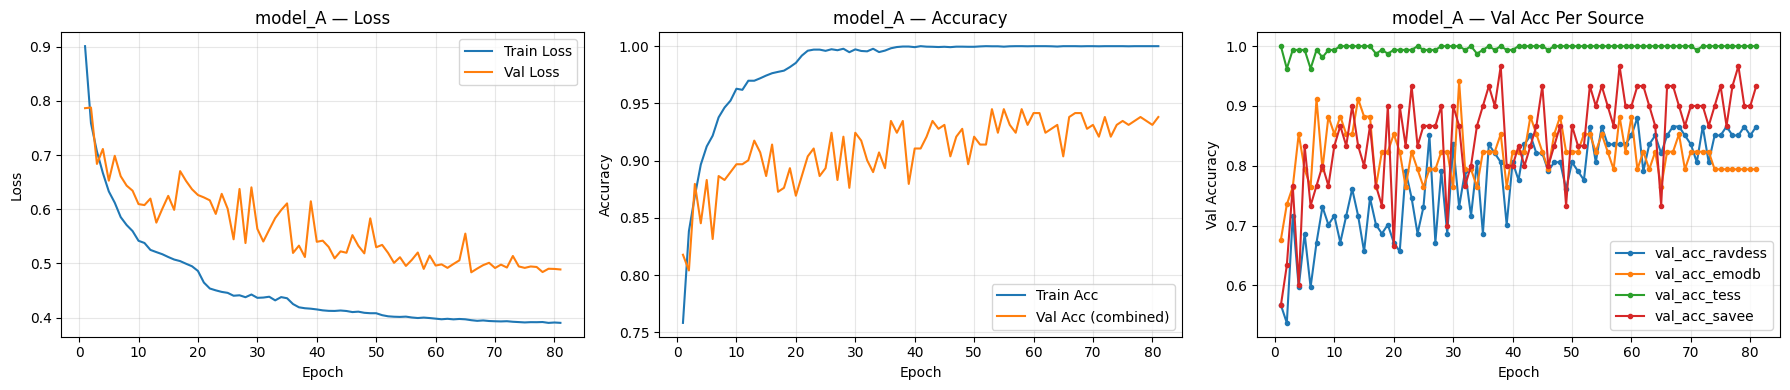

Plot saved: /content/drive/MyDrive/TA_SER/reports/training_curves_A.png


In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history.history['loss'], label='Train Loss')
axes[0].plot(epochs, history.history['val_loss'], label='Val Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history['accuracy'], label='Train Acc')
axes[1].plot(epochs, history.history['val_accuracy'], label='Val Acc (combined)')
axes[1].set_title(f'{MODEL_NAME} — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

for src, acc_list in per_source_callback.history_per_source.items():
    axes[2].plot(range(1, len(acc_list)+1), acc_list, label=f'val_acc_{src}', marker='.')
axes[2].set_title(f'{MODEL_NAME} — Val Acc Per Source')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Val Accuracy')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
curves_path = REPORTS_DIR / f'training_curves_{MODEL_NAME[-1]}.png'
plt.savefig(curves_path, dpi=100, bbox_inches='tight')
plt.show()

print(f'Plot saved: {curves_path}')


In [ ]:
print('=' * 60)
print(f'MODEL A (Single-Branch Baseline) — Training Summary')
print('=' * 60)
print(f'Total params          : {total_params:,}')
print(f'Epochs trained        : {len(history.history["loss"])}')
print(f'Best val_loss         : {min(history.history["val_loss"]):.4f}')
print(f'Best val_acc (combined): {max(history.history["val_accuracy"]):.4f}')
print()
print('Final val_acc per source:')
for src, acc_list in per_source_callback.history_per_source.items():
    print(f'  {src:8s}: last={acc_list[-1]:.3f}  best={max(acc_list):.3f}')
print()
print(f'Checkpoint saved: {checkpoint_path}')
print(f'History saved   : {history_path}')
print(f'Plot saved      : {curves_path}')


MODEL A (Single-Branch Baseline) — Training Summary
Total params          : 253,252
Epochs trained        : 81
Best val_loss         : 0.4837
Best val_acc (combined): 0.9450

Final val_acc per source:
  ravdess : last=0.866  best=0.881
  emodb   : last=0.794  best=0.941
  tess    : last=1.000  best=1.000
  savee   : last=0.933  best=0.967

Checkpoint saved: /content/drive/MyDrive/TA_SER/saved_models/v4/model_A_best.h5
History saved   : /content/drive/MyDrive/TA_SER/saved_models/v4/history_A.json
Plot saved      : /content/drive/MyDrive/TA_SER/reports/training_curves_A.png
